<a href="https://colab.research.google.com/github/nicolaiberk/llm_ws/blob/main/notebooks/02a_embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Intro to embedding manipulation with `gensim`

To use word embeddings, we will use a package called `gensim`. As it is not installed in Colab by default, we first need to install it using the package manager pip. The ! signifies that this is a system command, not python code.

In [1]:
!pip install gensim # restart after installation

  Obtaining dependency information for numpy<2.0,>=1.18.5 from https://files.pythonhosted.org/packages/75/5b/ca6c8bd14007e5ca171c7c03102d17b4f4e0ceb53957e8c44343a9546dcc/numpy-1.26.4-cp312-cp312-macosx_11_0_arm64.whl.metadata
  Using cached numpy-1.26.4-cp312-cp312-macosx_11_0_arm64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-macosx_11_0_arm64.whl (13.7 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.

[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## Word Embeddings from Pre-Trained Models

In [2]:
## we load a 100-dimensional GloVe model trained on Wikipedia data
import gensim.downloader as api
wv = api.load('glove-wiki-gigaword-100') # small model so we don't have to wait too long...

In [3]:
wv['ziti'] # what do our embeddings look like?

array([ 0.049439 ,  0.33049  , -0.62916  ,  0.05941  , -0.070866 ,
       -0.31198  ,  1.0051   , -0.36994  ,  0.51071  ,  0.88759  ,
        0.30675  ,  0.41871  , -0.20705  ,  0.54854  ,  0.2315   ,
       -0.10115  , -0.44656  ,  0.022504 ,  0.31798  ,  0.44769  ,
       -0.50513  ,  0.34741  , -0.069257 ,  0.22331  ,  0.41969  ,
        0.27958  ,  0.0037731, -0.22206  , -0.60191  , -0.67105  ,
        0.1164   ,  0.099292 ,  0.16863  , -0.69876  ,  0.13203  ,
        0.14845  ,  0.020125 , -0.40887  ,  0.15019  , -0.25258  ,
        0.69223  , -0.24897  ,  0.047037 , -0.33101  , -0.16142  ,
        0.10763  , -0.06854  , -0.29817  ,  0.15847  ,  0.92439  ,
        0.52995  ,  0.89365  ,  0.56876  , -0.2421   , -0.78985  ,
        0.75897  ,  0.53027  ,  0.53722  , -0.94077  ,  0.0013162,
       -0.12927  , -0.10485  , -0.059788 , -0.56039  , -0.38289  ,
       -0.43905  ,  0.02313  , -0.27358  , -0.086559 , -0.54393  ,
       -0.49323  ,  0.14044  ,  0.50186  ,  0.11039  , -0.4033

### Get most similar words

In [4]:
## so what are 'ziti' according to our model? Let's check the most similar embeddings:
print(wv.most_similar(positive=['ziti'], topn=5))

[('rigatoni', 0.7073922753334045), ('penne', 0.6969300508499146), ('focaccia', 0.6311710476875305), ('rotini', 0.626558780670166), ('scrod', 0.6251025199890137)]


In [5]:
## you can assess the similarity to other words with the `similarity` function (we'll cover what this score is later today)
wv.similarity('ziti', 'penne')

0.69693005

In [6]:
# Whereas
wv.similarity('ziti', 'banana')

0.15077046

In [7]:
# and
wv.similarity('ziti', 'car')

-0.2821738

In [8]:
## You can calculate with these embeddings:
wv_london = wv['paris'] - wv['france'] + wv['england']
print(wv.most_similar(positive=[wv_london], topn=5))

[('london', 0.7929531931877136), ('england', 0.7346791625022888), ('melbourne', 0.7304184436798096), ('sydney', 0.7011193037033081), ('perth', 0.6856114268302917)]


In [9]:
## Though it does not always work perfectly
wv_queen = wv['king'] + wv['woman'] - wv['man']
print(wv.most_similar(positive=[wv_queen], topn=5))

[('king', 0.8551837205886841), ('queen', 0.783441424369812), ('monarch', 0.6933802366256714), ('throne', 0.6833109259605408), ('daughter', 0.680908203125)]


In [10]:
## you can also use the inbuilt function to get weighted averages
print(wv.most_similar(positive=['woman', 'king'], negative=['man'], topn=5))

[('queen', 0.7698541283607483), ('monarch', 0.6843380331993103), ('throne', 0.6755736470222473), ('daughter', 0.6594556570053101), ('princess', 0.6520534157752991)]


In [11]:
## other cute functions
print(wv.doesnt_match(['fire', 'water', 'land', 'sea', 'air', 'car']))

car


### Training your own Model

We'll use an adapted dataset of dialogue in the Simpsons from [Kaggle](https://www.kaggle.com/datasets/prashant111/the-simpsons-dataset?resource=download&select=simpsons_script_lines.csv).

![](https://media.giphy.com/media/v1.Y2lkPWVjZjA1ZTQ3cHA1dDZ5MWUwOWIyMmd3dHk3MGNyNGdvamEzc2w2dzVjdzdvMW5wOCZlcD12MV9naWZzX3NlYXJjaCZjdD1n/tkYpAbKdWj4TS/giphy.gif)

In [12]:
## load data
import pandas as pd
dataset = pd.read_csv('https://www.dropbox.com/scl/fi/n5ffxvm4qyjkp8ws7qgoq/simpsons_script_lines_clean.csv?rlkey=gfliitwgi8cqsjxlcdmmdwtym&dl=1')
dataset.head()

,id,raw_character_text,spoken_words
0,9549,Miss Hoover,"No, actually, it was a little of both. Sometim..."
1,9550,Lisa Simpson,Where's Mr. Bergstrom?
2,9551,Miss Hoover,I don't know. Although I'd sure like to talk t...
3,9552,Lisa Simpson,That life is worth living.
4,9553,Edna Krabappel-Flanders,The polls will be open from now until the end ...


In [13]:
## clean the texts (very rough here)
dataset['cleaned_text'] = dataset['spoken_words'].str.replace('[^a-zA-Z ]','', regex=True) # remove anything that is not a letter or whitespace
dataset['cleaned_text'] = dataset['cleaned_text'].str.lower() # lowercase
dataset['cleaned_text'] = dataset['cleaned_text'].str.replace(' +', ' ', regex=True) # remove multiple whitespaces

In [14]:
dataset.cleaned_text.head()

0    no actually it was a little of both sometimes ...
1                                  wheres mr bergstrom
2    i dont know although id sure like to talk to h...
3                            that life is worth living
4    the polls will be open from now until the end ...
Name: cleaned_text, dtype: object

In [15]:
## filter empty rows and enforce string
dataset = dataset[dataset['cleaned_text'] != '']
dataset.loc[:,'cleaned_text'] = dataset['cleaned_text'].astype(str)

In [16]:
## how many texts are left?
dataset.shape

(158239, 4)

In [17]:
## create a list of lists of words by splitting along whitespaces
sentences = [s.split(" ") for s in dataset['cleaned_text']]

In [18]:
sentences[1] # the pre-processing is not perfect

['wheres', 'mr', 'bergstrom']

In [19]:
## load dataset (use an iterator for larger datasets: https://radimrehurek.com/gensim/auto_examples/tutorials/run_word2vec.html#training-your-own-model)
from gensim.models import Word2Vec

## estimate a model and save
model = Word2Vec(
    sentences=sentences,
    vector_size=100,  # number of dimensions of word embeddings
    window=5,         # number of context words in either direction to include
    min_count=5,      # how often must a word appear to enter the corpus?
    workers=4         # how many CPUs should be used to fit the model?
    )
model.save("simpsons.w2v.model")

In [20]:
## what is the main output?
model.wv.vectors.shape

(11697, 100)

In [21]:
## assess model
model.wv.most_similar('homer', topn=5)

[('marge', 0.831714391708374),
 ('bart', 0.8228544592857361),
 ('lisa', 0.7873004078865051),
 ('grampa', 0.7184996008872986),
 ('abe', 0.7027376294136047)]

In [22]:
## subset words of interest
interesting_words = [
    'banana', 'pineapple', 'mango',
    'car', 'bike', 'motorcycle',
    'bart', 'lisa', 'homer']
interesting_vecs = wv[interesting_words]

In [23]:
## dimensionality reduction using PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(interesting_vecs)
wv_2d = pca.transform(interesting_vecs)
wv_2d = pd.DataFrame(wv_2d, index = interesting_words)

In [24]:
wv_2d

,0,1
banana,3.541009,1.041963
pineapple,4.103635,1.062510
mango,3.847255,0.803716
car,-3.141654,2.390038
bike,-2.633529,1.914495
motorcycle,-2.883575,2.724190
bart,-1.347623,-3.186925
lisa,0.255806,-3.397163
homer,-1.741323,-3.352823


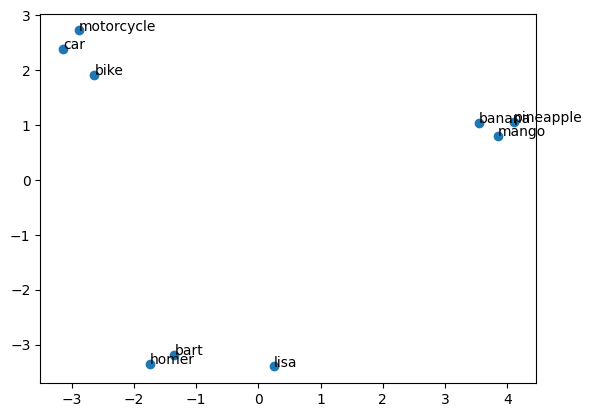

In [25]:
import matplotlib.pyplot as plt

plt.scatter(wv_2d[0], wv_2d[1])

for i in wv_2d.index:
    plt.annotate(i, (wv_2d[0][i], wv_2d[1][i]))

plt.show()

In [26]:
## subset words of interest
interesting_words = [
    'paris', 'berlin', 'france', 'germany']
interesting_vecs = wv[interesting_words]

In [27]:
## dimensionality reduction
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(interesting_vecs)
wv_2d = pca.transform(interesting_vecs)
wv_2d = pd.DataFrame(wv_2d, index = interesting_words)

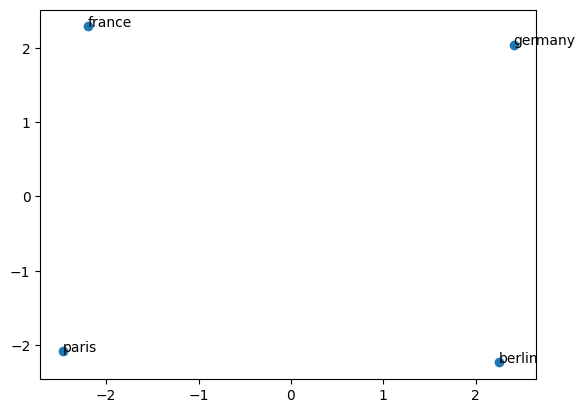

In [28]:
import matplotlib.pyplot as plt
import random

random.seed(0)

plt.scatter(wv_2d[0], wv_2d[1])

for i in wv_2d.index:
    plt.annotate(i, (wv_2d[0][i], wv_2d[1][i]))

plt.show()

## Exercise

1) Calculate the word vector for Berlin from the vectors for 'paris', 'france', and 'germany'. Explain your reasoning.

In [ ]:
## your answer

2) Assess the most similar words to this vector.

In [ ]:
## your answer

3) Plot the calculated vector into the same vector space alongside paris, france, germany, and berlin using PCA.

In [ ]:
## your answer

4) We have trained these embeddings on a dataset from the simpsons, a popular cartoon series. What consequences might this choice of data have for the word embeddings? How might this compare to a corpus trained on Wikipedia data?

**Your answer**


5) Try to find an interesting bias in the data by looking at word similarities

In [ ]:
## your answer

# Scaling Word Embeddings

In [39]:
import numpy as np

## Calculating Projections and Cosine Similarity

In [30]:
## again we load the 100-dimensional GloVe model trained on Wikipedia data
import gensim.downloader as api
wv = api.load('glove-wiki-gigaword-100')

We can calculate the projection of vector a on a given vector b by using the dot product, divided by the magnitude of vector b:

In [31]:
## calculate dot product
from numpy import dot
from numpy.linalg import norm

def proj_mag(a, b):
    return dot(a, b) / norm(b)

proj_mag(wv['nurse'], wv['woman'])

3.328134

But cosine similarity is a lot easier to interpret, since it is bounded [-1,1]:

In [32]:
def cos_sim(a, b):
    return dot(a, b)/(norm(a)*norm(b))

cos_sim(wv['nurse'], wv['woman'])

0.61394423

As you have seen in the first tutorial, there is also a function in the `gensim`-package to calculate the cosine similarity:

In [33]:
wv.similarity('nurse', 'woman')

0.61394423

## Defining Scales

An association of a given word might not tell us much, especially because opposite concepts are often located close to each other in the vector space. Rather than the association of two words, we might often be interested in the relative position of a concept on a pre-defined scale. We can create such a scale by subtracting the negative pole of that scale from the positive pole. You have seen this concept being used already when we calculated the word vector for 'berlin' from the vectors for 'paris', 'france', and 'germany'. Try to imagine this subtraction in the vector space.

By calculating the magnitude of the projection of a given word to this defined axis, we can identify the position this word has relative to this scale. This visualization from the Kozlowski paper might be helpful to understand this concept:

![](https://www.dropbox.com/scl/fi/fy9ihaxiwiql2c0s13vjy/projection_example.png?rlkey=aszlo5mp3rdzy4svawug5eybl&dl=1)

You can hence create pretty much any scale by defining two poles for it, subtracting the negative from the positive pole, and calculating the magnitude of the projection:

In [34]:
## simple scaling, projection magnitude
fr_de_scale = wv['french'] - wv['german']
print("Frenchness of Paris: ", proj_mag(wv['paris'], fr_de_scale))
print("Frenchness of Lausanne: ", proj_mag(wv['lausanne'], fr_de_scale))
print("Frenchness of Bern: ", proj_mag(wv['bern'], fr_de_scale))
print("Frenchness of Berlin: ", proj_mag(wv['berlin'], fr_de_scale))

Frenchness of Paris:  1.8724234
Frenchness of Lausanne:  0.38790774
Frenchness of Bern:  -0.8462114
Frenchness of Berlin:  -1.8756536


As mentioned, the boundedness of the cosine similarity [-1,1] makes it a lot more interpretable:

In [35]:
## simple scaling, cosine similarity
fr_de_scale = wv['french'] - wv['german']
print("Frenchness of Paris: ", cos_sim(wv['paris'], fr_de_scale))
print("Frenchness of Lausanne: ", cos_sim(wv['lausanne'], fr_de_scale))
print("Frenchness of Bern: ", cos_sim(wv['bern'], fr_de_scale))
print("Frenchness of Berlin: ", cos_sim(wv['berlin'], fr_de_scale))

Frenchness of Paris:  0.29809454
Frenchness of Lausanne:  0.0726039
Frenchness of Bern:  -0.17677024
Frenchness of Berlin:  -0.3329


# BONUS CONTENT

## More on Scaling

In practice, it is better to create a scale from an averaged vector of multiple pole words (often referred to as the 'centroid'). To do so, we define our pole words and average across their vectors:

In [36]:
## start by defining dictionaries (usually larger than 3-4 words)
rich_words = ['rich', 'wealthy', 'wealth', 'billionaire']
poor_words = ['poor', 'broke', 'poverty', 'beggar']

female_words = ['female', 'woman', 'feminine']
male_words = ['male', 'man', 'masculine']

In [37]:
## pro tip: you can extend your dictionaries with embeddings!
wv.most_similar(positive=rich_words, topn=5)

[('fortune', 0.6519295573234558),
 ('richest', 0.6483081579208374),
 ('money', 0.620699405670166),
 ('vast', 0.6197866201400757),
 ('businessman', 0.619742751121521)]

In [40]:
## create mean vectors for your concepts of interest
rich_vec = np.mean(wv[rich_words], axis = 0)
poor_vec = np.mean(wv[poor_words], axis = 0)

female_vec = np.mean(wv[female_words], axis = 0)
male_vec = np.mean(wv[male_words], axis = 0)

Try to imagine what these vectors look like in the vector space, relative to the dictionary terms. These vectors can already be informative in themselves, given that they are designed to represent the essence of a concept:

In [41]:
cos_sim(wv['nurse'], female_vec)

0.5050167

In [42]:
cos_sim(wv['nurse'], male_vec)

0.4016291

And the differences of cosine similarities are often used in research:

In [43]:
## cosine similarity difference
nurse_mf_cos = cos_sim(wv['nurse'], female_vec) - cos_sim(wv['nurse'], male_vec)
teacher_mf_cos = cos_sim(wv['teacher'], female_vec) - cos_sim(wv['teacher'], male_vec)
lifeguard_mf_cos = cos_sim(wv['lifeguard'], female_vec) - cos_sim(wv['lifeguard'], male_vec)
banker_mf_cos = cos_sim(wv['banker'], female_vec) - cos_sim(wv['banker'], male_vec)
miner_mf_cos = cos_sim(wv['miner'], female_vec) - cos_sim(wv['miner'], male_vec)

print("Association of 'nurse' with female (vs. male) terms: ", nurse_mf_cos)
print("Association of 'teacher' with female (vs. male) terms: ", teacher_mf_cos)
print("Association of 'lifeguard' with female (vs. male) terms: ", lifeguard_mf_cos)
print("Association of 'banker' with female (vs. male) terms: ", banker_mf_cos)
print("Association of 'miner' with female (vs. male) terms: ", miner_mf_cos)

Association of 'nurse' with female (vs. male) terms:  0.103387594
Association of 'teacher' with female (vs. male) terms:  0.023278862
Association of 'lifeguard' with female (vs. male) terms:  0.0648001
Association of 'banker' with female (vs. male) terms:  -0.034258217
Association of 'miner' with female (vs. male) terms:  -0.0060281903


However, the neat nature of projections is that they can capture a vectors' position on that very scale. To calculate them, we first need subtract the poles from each other to create the axes:

In [44]:
## define axes
gender_axis = female_vec - male_vec
rich_axis = rich_vec - poor_vec

... and calculate the cosine similarities:

In [45]:
import numpy as np
import pandas as pd

scaled_occupations = pd.DataFrame(
    [['Nurse', 'Teacher', 'Lifeguard', 'Banker', 'Miner'],
    [
        cos_sim(wv['nurse'], gender_axis),
        cos_sim(wv['teacher'], gender_axis),
        cos_sim(wv['lifeguard'], gender_axis),
        cos_sim(wv['banker'], gender_axis),
        cos_sim(wv['miner'], gender_axis)
    ],
    [
        cos_sim(wv['nurse'], rich_axis),
        cos_sim(wv['teacher'], rich_axis),
        cos_sim(wv['lifeguard'], rich_axis),
        cos_sim(wv['banker'], rich_axis),
        cos_sim(wv['miner'], rich_axis)
    ]]
).T.rename(columns={0:'Occupation', 1:'Gender score', 2:'Economic Score'})

In [46]:
scaled_occupations

,Occupation,Gender score,Economic Score
0,Nurse,0.379125,-0.24585
1,Teacher,0.160878,-0.117471
2,Lifeguard,0.196767,-0.295412
3,Banker,-0.049261,0.455049
4,Miner,0.027395,0.13554


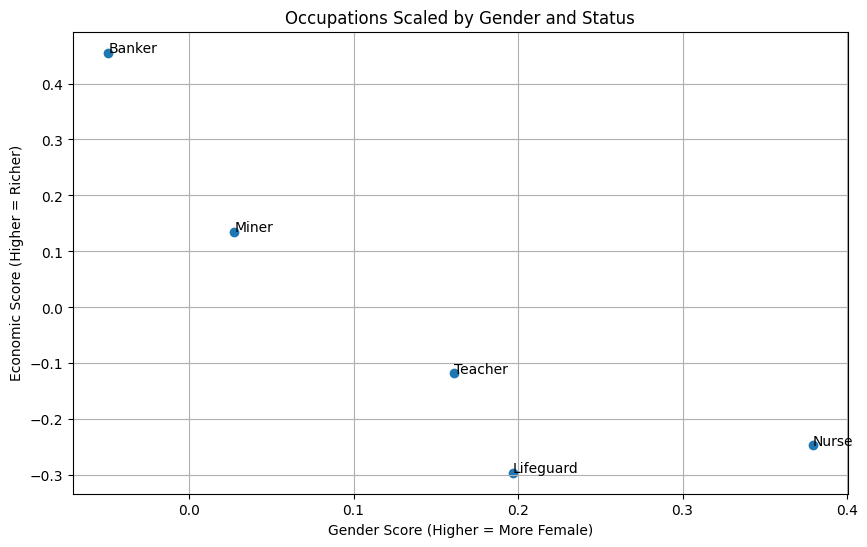

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(scaled_occupations['Gender score'], scaled_occupations['Economic Score'])

# Add labels and title
plt.xlabel('Gender Score (Higher = More Female)')
plt.ylabel('Economic Score (Higher = Richer)')
plt.title('Occupations Scaled by Gender and Status')

# Add text labels for each point
for i, row in scaled_occupations.iterrows():
    plt.text(row['Gender score'], row['Economic Score'], row['Occupation'])

plt.grid(True)
plt.show()

In practice, both approaches (differences in cosine similarities and the cosine similarity relative to a scale) lead to almost identical scores:

In [48]:
scaled_occupations['cos_dif_gender'] = [nurse_mf_cos, teacher_mf_cos, lifeguard_mf_cos, banker_mf_cos, miner_mf_cos]
scaled_occupations[['Gender score', 'cos_dif_gender']].corr()

,Gender score,cos_dif_gender
Gender score,1.000000,0.980181
cos_dif_gender,0.980181,1.000000


## Document Embeddings

We'll return to the adapted dataset of dialogue in the Simpsons from [Kaggle](https://www.kaggle.com/datasets/prashant111/the-simpsons-dataset?resource=download&select=simpsons_script_lines.csv). This time, we estimate a model with document embeddings indicating the character who provided the line. This allows us to create semantic vectors for each character in the same space as the word embeddings.

Again, we load and clean our texts:

In [ ]:
## load data
import pandas as pd
dataset = pd.read_csv('https://www.dropbox.com/scl/fi/n5ffxvm4qyjkp8ws7qgoq/simpsons_script_lines_clean.csv?rlkey=gfliitwgi8cqsjxlcdmmdwtym&dl=1')
dataset['cleaned_text'] = dataset['spoken_words'].str.replace('[^a-zA-Z ]','', regex=True) # remove anything that is not a letter or whitespace
dataset['cleaned_text'] = dataset['cleaned_text'].str.lower() # lowercase
dataset['cleaned_text'] = dataset['cleaned_text'].str.replace(' +', '') # remove multiple whitespaces
dataset = dataset[dataset['cleaned_text'] != '']
dataset.loc[:,'cleaned_text'] = dataset['cleaned_text'].astype(str)
dataset.cleaned_text.head()

We then need to prepare this data for the Doc2Vec-model. Remember that, alongside the vector indicating context words, a vector indicating the document ID is passed. We need to concatenate all texts per speaker in order to create a single 'document' for each speaker. Then, we split those documents into tokens of interest (in our case words, similar to the word2vec model) and use  `gensim`'s `TaggedDocument`-class to pass the information about the speaker:

In [ ]:
## concatenate all cleaned texts from the same speaker and tag documents (this runs a bit)
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
character_texts = list()
for speaker in dataset.raw_character_text.unique():
    print('Preparing texts from ', speaker, '...')
    concat_text = ' '.join(dataset[dataset.raw_character_text == speaker].cleaned_text)
    character_texts.append(TaggedDocument(concat_text.split(" "), [speaker]))

Each document then contains all words uttered from a given character, as well as an indicator for the character:

In [ ]:
character_texts[1100]

Time to define our model and train it on these documents!

In [ ]:
model = Doc2Vec(vector_size=300, min_count=2, epochs=40)

In [ ]:
## estimate doc2vec model (this takes some patience)
model.build_vocab(character_texts)
model.train(character_texts, total_examples=model.corpus_count, epochs=model.epochs)

This results in a model with both word and document embeddings. These can be accessed via `model.dv`:

In [ ]:
model.dv['Homer Simpson'].shape

In [ ]:
model.wv['donut'].shape

Crucially, the document embeddings are learned into the same vector space as the word embeddings. This means we can assess which words are associated with this character, meaning which words are similar in meaning as the learned the meaning of the character (note that words are predictive of words used by the character - they might not even be used by the characters themselves).

In [ ]:
model.wv.most_similar(model.dv['Homer Simpson'], topn=5)

In [ ]:
model.wv.most_similar(model.dv['Lisa Simpson'], topn=5)

Of course, we can also plot the positions of different characters in our vector space:

In [ ]:
## run a dimensionality reduction
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(model.dv[model.dv.index_to_key])
dv_2d = pca.transform(model.dv[model.dv.index_to_key])
dv_2d = pd.DataFrame(dv_2d, index = model.dv.index_to_key)

In [ ]:
import matplotlib.pyplot as plt
import random
random.seed(0)

plt.scatter(dv_2d[0], dv_2d[1])
plt.show()

And scale them:

In [ ]:
cool_boring_scale = model.wv['cool'] - model.wv['boring']
print("Coolness of Homer: ", cos_sim(model.dv['Homer Simpson'], cool_boring_scale))
print("Coolness of Bart: ", cos_sim(model.dv['Bart Simpson'], cool_boring_scale))

In [ ]:
## ...or predict vectors for new documents...
new_document = [
    "it", "wont", "last", "brothers", "and", "sisters", "are", "natural",
    "enemies", "like", "englishmen", "and", "scots", "or", "welshmen", "and",
    "scots", "or", "japanese", "and", "scots", "or", "scots", "and", "other",
    "scots", "damn", "scots", "they", "ruined", "scotland"
]
vector= model.infer_vector(new_document)

In [ ]:
## ...and compare them
model.dv.most_similar([vector], topn=5)

## Exercise

1) You are interested in the political leaning of the characters. How could you measure their political leaning, based on their language?

2) Define dictionaries to measure your concept of interest.

3) Create a scale (or if you are very eager, two). Select some characters of interest that you would like to scale. Calculate the cosine similarity of their vectors relative to the scale.

4) Create a table of the political leanings of your characters. What do you observe? Who do you think might vote republican?

5) Estimate the political leaning of all characters and create a plot of their distribution.